In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-o9gu3_gy
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-o9gu3_gy
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import math
from pathlib import Path
from PIL import Image, UnidentifiedImageError
Image.MAX_IMAGE_PIXELS = None  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm, trange
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as T
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from torchvision.models import efficientnet_v2_l, EfficientNet_V2_L_Weights
from torchvision.models import regnet_y_16gf, RegNet_Y_16GF_Weights
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision.models import swin_v2_b, Swin_V2_B_Weights
import clip
import torch.optim.lr_scheduler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# CONFIG
# INPUT_SIZE = 300 #efficientnet
# INPUT_SIZE = 384 
INPUT_SIZE = 336
# BATCH_SIZE = 16
BATCH_SIZE = 8
NUM_EPOCHS = 30
ALPHA = 0.5
BETA = 0.5
EARLY_STOP_PATIENCE = 6
DROPOUT_RATE = 0.4
NUM_WORKERS = 2

In [ ]:
# CONFIGURATION FOR CLIP
CLIP_MODEL_NAME = "ViT-L/14@336px"
NEW_FC_INPUT_FEATURES = 768

import clip
clip_model, clip_preprocess = clip.load(CLIP_MODEL_NAME, device=device, jit=False)
clip_base = clip_model.visual 
CLIP_DTYPE = torch.float32 

clip_base.to(CLIP_DTYPE) 


class MultiClassWildfireModel(nn.Module):
    def __init__(self, num_multi=5, clip_encoder=None, clip_dtype=torch.float32, dropout_rate=0.3):
        super().__init__()
        
        self.base = clip_encoder
        self.clip_dtype = clip_dtype 
        in_features = NEW_FC_INPUT_FEATURES
        
        self.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)
        )

        self.multi = nn.Linear(256, num_multi)

    def forward(self, x):
        
        x = self.base(x) 
        x = self.fc(x)
        return self.multi(x)

model = MultiClassWildfireModel(
    num_multi=5, 
    clip_encoder=clip_base, 
    clip_dtype=CLIP_DTYPE,
    dropout_rate=DROPOUT_RATE
).to(device)

for param in model.parameters(): 
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: CLIP ({CLIP_MODEL_NAME}) Full Fine-tuning (FLOAT32)")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Input size: 336x336")

100%|███████████████████████████████████████| 891M/891M [00:12<00:00, 77.4MiB/s]



Model: CLIP (ViT-L/14@336px) Full Fine-tuning (FLOAT32)
  Total parameters:     304,492,037
  Trainable parameters: 304,492,037
  Input size: 336x336


In [ ]:
#  Augmentation
train_transform_aug = T.Compose([
    T.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5,
        interpolation=T.InterpolationMode.BICUBIC
    ),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.RandomHorizontalFlip(p=0.5),
])

train_transform = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    train_transform_aug,
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True), 
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

val_test_transform = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True), 
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

In [6]:
# DATASET
class WildfireDataset(Dataset):
    """
    Dataset cho Method 2 với 2 outputs:
    - Binary label: fire (0) vs nofire (1)
    - Multi-class label: 5 subclasses (0-4)
    """
    SUBCLASS_MAP = {
        'Both_smoke_and_fire': 0,
        'Smoke_from_fires': 1,
        'Fire_confounding_elements': 2,
        'Forested_areas_without_confounding_elements': 3,
        'Smoke_confounding_elements': 4
    }

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self._load_samples()
        print(f"\nLoaded {len(self.samples)} images from {root_dir}")
        self._print_class_distribution()

    def _load_samples(self):
        for class_name in ['fire', 'nofire']:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                print(f"Warning: {class_dir} not found!")
                continue
            binary_label = 0 if class_name == 'fire' else 1

            for subclass_dir in class_dir.iterdir():
                if not subclass_dir.is_dir():
                    continue
                subclass_name = subclass_dir.name
                if subclass_name not in self.SUBCLASS_MAP:
                    print(f"Unknown subclass '{subclass_name}' — skipping")
                    continue
                multiclass_label = self.SUBCLASS_MAP[subclass_name]

                image_paths = list(subclass_dir.glob('*'))
                valid_images = [
                    img for img in image_paths
                    if img.suffix.lower() in ['.jpg', '.jpeg', '.png']
                ]
                for img_path in valid_images:
                    self.samples.append({
                        'path': img_path,
                        'binary_label': binary_label,
                        'multiclass_label': multiclass_label,
                        'subclass_name': subclass_name
                    })

    def _print_class_distribution(self):
        total = len(self.samples)
        if total == 0:
            print("No samples found!")
            return

        binary_counts = {0: 0, 1: 0}
        multi_counts = {i: 0 for i in range(5)}
        for sample in self.samples:
            binary_counts[sample['binary_label']] += 1
            multi_counts[sample['multiclass_label']] += 1

        print("Binary Class Distribution:")
        print(f"  Fire:   {binary_counts[0]:>5} ({binary_counts[0]/total*100:>5.1f}%)")
        print(f"  NoFire: {binary_counts[1]:>5} ({binary_counts[1]/total*100:>5.1f}%)")
        print("\nMulti-Class Distribution:")
        for name, idx in self.SUBCLASS_MAP.items():
            count = multi_counts[idx]
            print(f"  [{idx}] {name:<50}: {count:>5} ({count/total*100:>5.1f}%)")

    def get_class_counts(self):
        binary_counts = torch.zeros(2, dtype=torch.long)
        multi_counts = torch.zeros(5, dtype=torch.long)
        for sample in self.samples:
            binary_counts[sample['binary_label']] += 1
            multi_counts[sample['multiclass_label']] += 1
        return binary_counts, multi_counts

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            image = Image.open(sample['path']).convert('RGB')
        except (UnidentifiedImageError, OSError) as e:
            # Skip corrupted image by returning next index (safe fallback)
            alt_idx = (idx + 1) % len(self)
            return self.__getitem__(alt_idx)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'binary_label': torch.tensor(sample['binary_label'], dtype=torch.long),
            'multiclass_label': torch.tensor(sample['multiclass_label'], dtype=torch.long)
        }

In [7]:
# LOAD DATASETS & DATALOADERS
DATASET_PATH = Path('/kaggle/input/do-an-xu-ly-anh-va-ung-dung/the_wildfire_dataset/the_wildfire_dataset')

train_dataset = WildfireDataset(
    root_dir=DATASET_PATH / 'train',
    transform=train_transform
)

val_dataset = WildfireDataset(
    root_dir=DATASET_PATH / 'val',
    transform=val_test_transform
)

test_dataset = WildfireDataset(
    root_dir=DATASET_PATH / 'test',
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

print(f"\nDataLoaders Created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")


Loaded 1887 images from /kaggle/input/do-an-xu-ly-anh-va-ung-dung/the_wildfire_dataset/the_wildfire_dataset/train
Binary Class Distribution:
  Fire:     730 ( 38.7%)
  NoFire:  1157 ( 61.3%)

Multi-Class Distribution:
  [0] Both_smoke_and_fire                               :   269 ( 14.3%)
  [1] Smoke_from_fires                                  :   461 ( 24.4%)
  [2] Fire_confounding_elements                         :   236 ( 12.5%)
  [3] Forested_areas_without_confounding_elements       :   591 ( 31.3%)
  [4] Smoke_confounding_elements                        :   330 ( 17.5%)

Loaded 402 images from /kaggle/input/do-an-xu-ly-anh-va-ung-dung/the_wildfire_dataset/the_wildfire_dataset/val
Binary Class Distribution:
  Fire:     156 ( 38.8%)
  NoFire:   246 ( 61.2%)

Multi-Class Distribution:
  [0] Both_smoke_and_fire                               :    57 ( 14.2%)
  [1] Smoke_from_fires                                  :    99 ( 24.6%)
  [2] Fire_confounding_elements                       

In [8]:
# COMPUTE CLASS WEIGHTS
def compute_class_weights(counts: torch.Tensor):
    """Compute inverse-frequency normalized weights (float tensor)."""
    counts = counts.float()
    # Avoid division by zero
    counts = torch.where(counts == 0, torch.ones_like(counts), counts)
    total = counts.sum()
    weights = total / (len(counts) * counts)
    return weights

binary_counts, multi_counts = train_dataset.get_class_counts()
binary_weights = compute_class_weights(binary_counts)
multi_weights = compute_class_weights(multi_counts)

# Move weights to device for criterion
binary_weights = binary_weights.to(device)
multi_weights = multi_weights.to(device)

print("\nBinary weights:", binary_weights)
print("Multi weights:", multi_weights)


Binary weights: tensor([1.2925, 0.8155], device='cuda:0')
Multi weights: tensor([1.4030, 0.8187, 1.5992, 0.6386, 1.1436], device='cuda:0')


In [ ]:
# TRAINING SETUP
# criterion_multiclass = nn.CrossEntropyLoss(weight=multi_weights)
criterion_multiclass = nn.CrossEntropyLoss()


# optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
optimizer = optim.AdamW(model.parameters(), lr=3e-6, weight_decay=0.05) 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',         
    factor=0.5,         
    patience=2,         
    verbose=True
)

# Early stopping
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\nConfiguration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Optimizer: AdamW (weight_decay=0.01)")
print(f"  Loss weights: α={ALPHA}, β={BETA}")
print(f"  Early stopping patience: {EARLY_STOP_PATIENCE}")
print(f"  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)") 


Configuration:
  Epochs: 30
  Batch size: 8
  Optimizer: AdamW (weight_decay=0.01)
  Loss weights: α=0.5, β=0.5
  Early stopping patience: 6
  LR Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [10]:
def train_one_epoch_multiclass(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    preds_all, labels_all = [], []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        images = batch['image'].to(device)
        labels = batch['multiclass_label'].to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds_all.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    acc = accuracy_score(labels_all, preds_all)
    return {'loss': epoch_loss, 'multi_acc': acc}

@torch.no_grad()
def validate_multiclass(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all, labels_all = [], []

    for batch in tqdm(dataloader, desc='Validation', leave=False):
        images = batch['image'].to(device)
        labels = batch['multiclass_label'].to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        preds_all.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    acc = accuracy_score(labels_all, preds_all)
    return {'loss': epoch_loss, 'multi_acc': acc}
    

In [11]:
# MAIN TRAINING LOOP WITH EARLY STOP COUNT
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60 + "\n")

history = {'train_loss': [], 'val_loss': [], 'train_multi_acc': [], 'val_multi_acc': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
early_stop_count = 0  

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_metrics = train_one_epoch_multiclass(model, train_loader, criterion_multiclass, optimizer, device)
    val_metrics = validate_multiclass(model, val_loader, criterion_multiclass, device)

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_multi_acc'].append(train_metrics['multi_acc'])
    history['val_multi_acc'].append(val_metrics['multi_acc'])

    print(f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['multi_acc']:.4f}")
    print(f"Val   Loss={val_metrics['loss']:.4f}, Val   Acc={val_metrics['multi_acc']:.4f}")

    scheduler.step(val_metrics['loss']) #test learning rate
    
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_model_state, 'best_multiclass_model_state.pth')
        print(f"New best model saved (Val Loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"Patience counter: {patience_counter}/{EARLY_STOP_PATIENCE}")
        if patience_counter >= EARLY_STOP_PATIENCE:
            early_stop_count += 1
            print("Early stopping triggered")
            break

# After training
print(f"\nNumber of times early stopping would have triggered: {early_stop_count}")


STARTING TRAINING


Epoch 1/30


Train Loss=0.8300, Train Acc=0.7515
Val   Loss=0.5900, Val   Acc=0.8507
New best model saved (Val Loss=0.5900)

Epoch 2/30


Train Loss=0.3945, Train Acc=0.8983
Val   Loss=0.5062, Val   Acc=0.8582
New best model saved (Val Loss=0.5062)

Epoch 3/30


Train Loss=0.2817, Train Acc=0.9295
Val   Loss=0.4170, Val   Acc=0.8856
New best model saved (Val Loss=0.4170)

Epoch 4/30


Train Loss=0.2296, Train Acc=0.9396
Val   Loss=0.4114, Val   Acc=0.8806
New best model saved (Val Loss=0.4114)

Epoch 5/30


...

Train Loss=0.0284, Train Acc=0.9974
Val   Loss=0.3956, Val   Acc=0.9154
Patience counter: 2/6

Epoch 13/30


Train Loss=0.0355, Train Acc=0.9931
Val   Loss=0.4464, Val   Acc=0.9030
Patience counter: 3/6

Epoch 14/30


Train Loss=0.0214, Train Acc=0.9974
Val   Loss=0.4691, Val   Acc=0.9005
Patience counter: 4/6

Epoch 15/30


Train Loss=0.0259, Train Acc=0.9952
Val   Loss=0.4189, Val   Acc=0.9005
Patience counter: 5/6

Epoch 16/30


Train Loss=0.0224, Train Acc=0.9968
Val   Loss=0.4393, Val   Acc=0.8980
Patience counter: 6/6
Early stopping triggered

Number of times early stopping would have triggered: 1


In [12]:
if best_model_state is not None:
    # load best onto model
    model.load_state_dict(best_model_state)
    model.to(device)
    print("Loaded best model for final test evaluation.")

Loaded best model for final test evaluation.


In [ ]:
# FINAL TEST EVALUATION 
print("\n" + "="*60)
print("FINAL TEST EVALUATION")
print("="*60 + "\n")

# Test
test_metrics = validate_multiclass(model, test_loader, criterion_multiclass, device)
print(f"Test Loss={test_metrics['loss']:.4f}, Test Multi-class Acc={test_metrics['multi_acc']:.4f}")

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(device)
        labels = batch['multiclass_label'].to('cpu').numpy()
        outputs = model(images)
        preds = outputs.argmax(dim=1).to('cpu').numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

# class_names = [
#     'Both_smoke_and_fire', 'Smoke_from_fires', 'Fire_confounding_elements',
#     'Forested_areas_without_confounding_elements', 'Smoke_confounding_elements'
# ]


FINAL TEST EVALUATION



Test Loss=0.3153, Test Multi-class Acc=0.9098


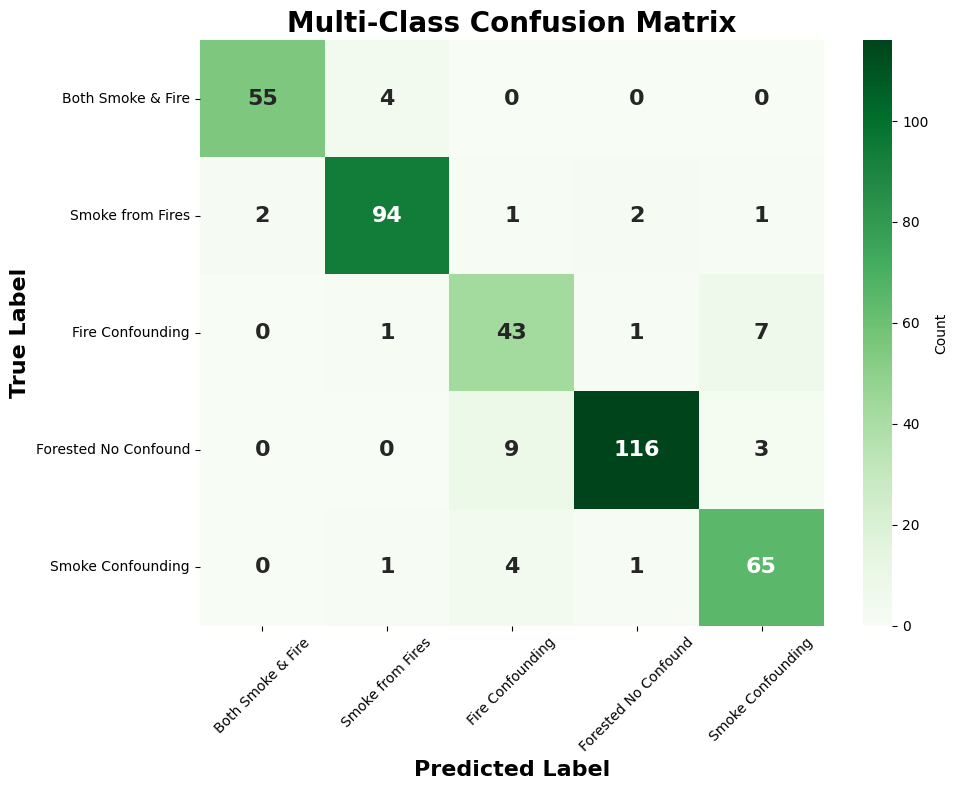

In [ ]:
class_names = [
    'Both Smoke & Fire',          # Both_smoke_and_fire
    'Smoke from Fires',           # Smoke_from_fires
    'Fire Confounding',           # Fire_confounding_elements
    'Forested No Confound',       # Forested_areas_without_confounding_elements
    'Smoke Confounding'           # Smoke_confounding_elements
]

# --- compute confusion matrix ---
cm_multi = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))  # tăng kích thước figure
sns.heatmap(
    cm_multi,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names[:cm_multi.shape[1]],
    yticklabels=class_names[:cm_multi.shape[0]],
    cbar_kws={'label': 'Count'},
    annot_kws={'fontsize': 16, 'fontweight': 'bold'}  # tăng font size
)

plt.title('Multi-Class Confusion Matrix', fontsize=20, fontweight='bold')
plt.ylabel('True Label', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=16, fontweight='bold')

plt.xticks(rotation=45)  
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_large.png', dpi=200, bbox_inches='tight')
plt.show()


PLOTTING TRAINING HISTORY
Saved training history plot to 'training_history_multiclass.png'


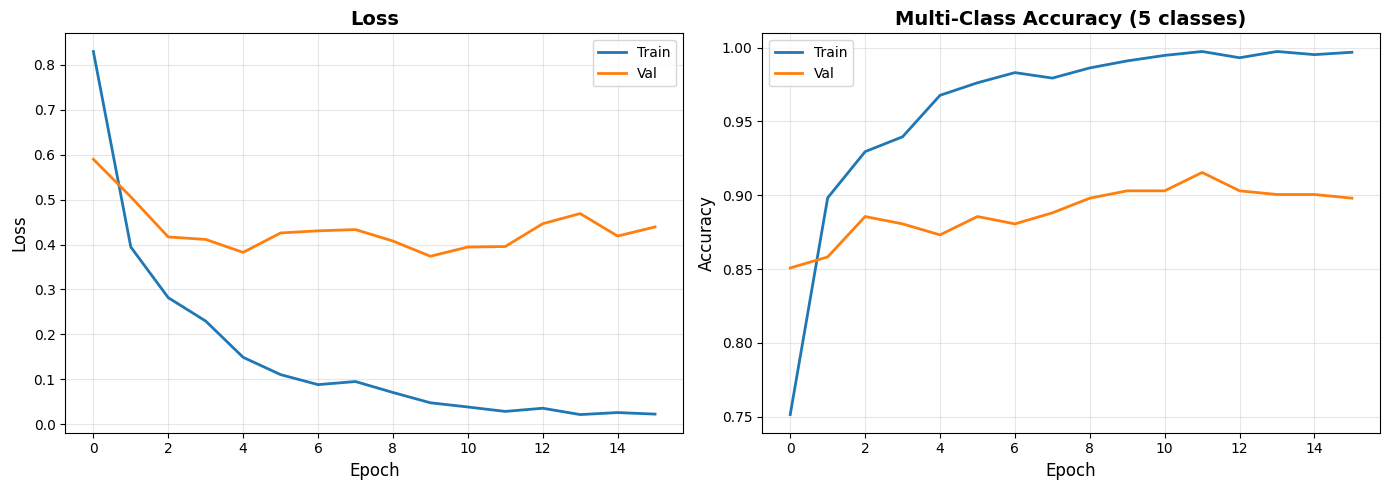

In [15]:
# PLOTTING TRAINING HISTORY
print("\n" + "="*60)
print("PLOTTING TRAINING HISTORY")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Multi-class Accuracy
axes[1].plot(history['train_multi_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_multi_acc'], label='Val', linewidth=2)
axes[1].set_title('Multi-Class Accuracy (5 classes)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_multiclass.png', dpi=150, bbox_inches='tight')
print("Saved training history plot to 'training_history_multiclass.png'")
plt.show()

In [16]:
print("\n" + "="*60)
print("SAVING MODEL & RESULTS")
print("="*60)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'test_metrics': test_metrics,
    'confusion_matrix': cm_multi.tolist(),
    'config': {
        'input_size': INPUT_SIZE,
        'num_epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': 1e-5,
        'architecture': 'ViT-L/14@336px',
        'total_params': total_params,
        'trainable_params': trainable_params
    }
}

torch.save(checkpoint, 'multiclass_wildfire_model.pth')
print("Model checkpoint saved to 'multiclass_wildfire_model.pth'")

# Save metrics CSV
metrics_df = pd.DataFrame({
    'epoch': list(range(1, len(history['train_loss']) + 1)),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_multi_acc': history['train_multi_acc'],
    'val_multi_acc': history['val_multi_acc']
})
metrics_df.to_csv('training_metrics_multiclass.csv', index=False)
print("Training metrics saved to 'training_metrics_multiclass.csv'")

test_results = pd.DataFrame([test_metrics])
test_results.to_csv('test_results_multiclass.csv', index=False)
print("Test results saved to 'test_results_multiclass.csv'")

print("\n" + "="*60)
print("ALL DONE!")
print("="*60)
print("\nGenerated files:")
print("  1. best_multiclass_model_state.pth - Best model state")
print("  2. multiclass_wildfire_model.pth  - Full checkpoint")
print("  3. training_history_multiclass.png - Training curves")
print("  4. confusion_matrix.png            - Confusion matrix")
print("  5. training_metrics_multiclass.csv - Metrics per epoch")
print("  6. test_results_multiclass.csv     - Final test results")


SAVING MODEL & RESULTS
Model checkpoint saved to 'multiclass_wildfire_model.pth'
Training metrics saved to 'training_metrics_multiclass.csv'
Test results saved to 'test_results_multiclass.csv'

ALL DONE!

Generated files:
  1. best_multiclass_model_state.pth - Best model state
  2. multiclass_wildfire_model.pth  - Full checkpoint
  3. training_history_multiclass.png - Training curves
  4. confusion_matrix.png            - Confusion matrix
  5. training_metrics_multiclass.csv - Metrics per epoch
  6. test_results_multiclass.csv     - Final test results
